In [1]:
import matplotlib.pyplot as plt
import pandas as pd

base_abc = pd.read_csv("Base_ABC_Flor-Colheita.csv")
base_abc.head()

,uuid_sub_talhao,uuid_talhao_safra,uuid_fazenda,Cooperativa,Safra,Altitude Mínima [m],Altitude Média [m],Altitude Máxima [m],Altitude Média [classe],Solo Grupo,...,ND.TMOL > 20 [sum],ND.TMOL > 22 [sum],ND.TMOL > 24 [sum],ND.TMOL > 26 [sum],ND.TMOL > 28 [sum],Amplitude Térmica [soma],ND.AMPLIT > 12 [sum],ND.AMPLIT > 16 [sum],ND.AMPLIT > 20 [sum],ND.AMPLIT > 24 [sum]
0,0017d88e-26bf-42d2-9f4c-7eb438fff2ed,0e113ef0-a96d-4380-a52c-b002144cc153,8daefa63-3408-4e07-98fb-edacea36073f,Castrolanda,2023/2024,778.0,815.0,846.0,801 a 900,Neossolos Litólicos Distróficos,...,"38,0","12,0","2,0","0,0","0,0","830,5","33,0","2,0","0,0","0,0"
1,0044b084-9661-4b71-8ef0-12190a6d2cc0,7106f884-5f42-4554-8404-8b3d38231a11,2a4d28e8-0574-4796-9d93-eea9200b7287,Castrolanda,2023/2024,971.0,989.0,1021.0,901 a 1000,Latossolos Vermelhos Distróficos,...,"24,0","0,0","0,0","0,0","0,0","909,0","27,0","5,0","0,0","0,0"
2,0047f2ed-6583-4163-93db-6f91e515f6a2,7dcfef66-0d93-4460-9cf3-f25fe26e7929,06a1c642-9a3a-42ea-ae98-a6670106741e,Castrolanda,2023/2024,983.0,998.0,1017.0,901 a 1000,Organossolos Mésicos,...,"13,0","0,0","0,0","0,0","0,0","821,0","41,0","8,0","0,0","0,0"
3,0058f085-a0ae-46cd-bdbf-821788eba645,09c5cc37-4160-4b3b-9b7a-4ecb0857288e,b2c741d1-e357-428f-8bbf-1ecba2b032c4,Castrolanda,2023/2024,984.0,1000.0,1017.0,901 a 1000,Latossolos Brunos Ácricos,...,"24,0","0,0","0,0","0,0","0,0","934,4","29,0","6,0","0,0","0,0"
4,005d144c-42b7-41cf-a042-8284f54dfe8e,fdb3a21a-0b0c-485d-8cbd-ddd80e4ea7f0,df74756c-5ff2-46b4-b307-d35e1c5c30d7,Castrolanda,2023/2024,961.0,1038.0,1078.0,1001 a 1100,Latossolos Vermelhos Distróficos,...,"13,0","3,0","0,0","0,0","0,0","402,9","15,0","5,0","0,0","0,0"


In [2]:
#variaveis utilizadas

variaveis = [ 
    "UF",
    "NH.TMED < 10 [sum]",
    "ND.TMIN < 10 [sum]",
    "Altitude Média [classe]",
    "Semeadura [data]",
    "Colheita [data]",
    "Genótipos Propósito",
    "Tipo Safra",
    "Solo Textura",
    "Talhão",
    "Solo Grupo",
    "Amplitude Térmica [soma]",
    "Temperatura Ar Mínima [soma]",
    "Temperatura Ar Máxima [soma]",
    "Fotoperiodo [soma]",
    "Genótipos",
    "Precipitação [soma]",
    "Graus Dias [soma]",
    "Temperatura Ar [soma]",
    "Umidade Relativa Máxima [soma]",
    "Umidade Relativa Mínima [soma]",
    "Umidade Relativa [soma]",
    "Radiação Solar [soma]",
    "Evapotranspiração Potencial PM [soma]",
    "Evapotranspiração Potencial PM2 [soma]",
    "Temperatura Orvalho [soma]",
    "Temperatura Ar Noturna [ºC]",
    "Temperatura Molhamento Foliar [soma]",
    "Altitude Máxima [m]",
    "Altitude Média [m]",
    "Altitude Mínima [m]",
    "NH.UR > 90 [sum]",
    "Ciclo Semeadura-Colheita [dias]",
    "Fungicida Planejado [aplicações]",
    "Herbicida Planejado [aplicações]",
    "Inseticida Planejado [aplicações]",
    "ND.UR < 60 [sum]",
    "ND.UR > 80 [sum]",
    "ND.UR > 90 [sum]",
    "NH.UR < 60 [sum]",
    "Talhão Latitude [grau decimal]",
    "Talhão Longitude [grau decimal]",
    "Colheita [decendio]",
    "ND.RAD < 10 [sum]",
    "ND.PREC > 5 [sum]",
    "NH.RAD > 800 [sum]",
    "Semeadura [decendio]",
    "ND.PREC = 0.0 [sum]",
    "ND.TMAX > 30 [sum]",
    "ND.PREC > 0.2 [sum]",
    "ND.RAD > 20 [sum]",
    "NH.RAD > 1000 [sum]",
    "NH.RAD > 600 [sum]",
]

base_abc_X  = base_abc[variaveis].copy()
base_abc_Y = base_abc["Produtividade Realizada [kg/ha]"]

#transformando as datas (melhor forma de trabalhar? Se for tratado como valor numérico, dia 2 tem mais importância que dia 1?)
base_abc_X["Semeadura [data]"] = pd.to_datetime(base_abc_X["Semeadura [data]"], errors='coerce')
base_abc_X["Colheita [data]"] = pd.to_datetime(base_abc_X["Colheita [data]"], errors='coerce')

for col in ["Semeadura [data]", "Colheita [data]"]:
    base_abc_X[f"{col}_ano"] = base_abc_X[col].dt.year
    base_abc_X[f"{col}_mes"] = base_abc_X[col].dt.month
    base_abc_X[f"{col}_dia"] = base_abc_X[col].dt.day

base_abc_X.head()

,UF,NH.TMED < 10 [sum],ND.TMIN < 10 [sum],Altitude Média [classe],Semeadura [data],Colheita [data],Genótipos Propósito,Tipo Safra,Solo Textura,Talhão,...,ND.PREC > 0.2 [sum],ND.RAD > 20 [sum],NH.RAD > 1000 [sum],NH.RAD > 600 [sum],Semeadura [data]_ano,Semeadura [data]_mes,Semeadura [data]_dia,Colheita [data]_ano,Colheita [data]_mes,Colheita [data]_dia
0,PR,"0,0","0,0",801 a 900,2023-10-11,2024-02-09,Grãos,Normal,Siltosa,PARAISO 100,...,"33,0","48,0","70,0","349,0",2023,10,11,2024,2,9
1,PR,"0,0","0,0",901 a 1000,2023-11-15,2024-03-29,Grãos,Normal,Argilosa,BAIRRO LUIS-75,...,"72,0","33,0","28,0","302,0",2023,11,15,2024,3,29
2,PR,"0,0","1,0",901 a 1000,2023-11-13,2024-03-06,Semente,Normal,NaN,MARJE 3,...,"45,0","29,0","37,0","242,0",2023,11,13,2024,3,6
3,PR,"0,0","0,0",901 a 1000,2023-11-05,2024-03-19,Semente,Normal,Argilosa,FAZENDA SAO GONCALO-70,...,"68,0","41,0","38,0","336,0",2023,11,5,2024,3,19
4,PR,"8,0","4,0",1001 a 1100,2023-09-13,2024-01-16,Semente,Normal,Argilosa,COTIA 4A,...,"19,0","13,0","0,0","86,0",2023,9,13,2024,1,16


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

variaveis_categoricas = [
    "UF",
    "Altitude Média [classe]",
    "Genótipos Propósito",
    "Tipo Safra",
    "Solo Textura",
    "Talhão",
    "Solo Grupo",
    "Genótipos"
]

variaveis_numericas = [
    "NH.TMED < 10 [sum]",
    "ND.TMIN < 10 [sum]",
    "Amplitude Térmica [soma]",
    "Temperatura Ar Mínima [soma]",
    "Temperatura Ar Máxima [soma]",
    "Fotoperiodo [soma]",
    "Precipitação [soma]",
    "Graus Dias [soma]",
    "Temperatura Ar [soma]",
    "Umidade Relativa Máxima [soma]",
    "Umidade Relativa Mínima [soma]",
    "Umidade Relativa [soma]",
    "Radiação Solar [soma]",
    "Evapotranspiração Potencial PM [soma]",
    "Evapotranspiração Potencial PM2 [soma]",
    "Temperatura Orvalho [soma]",
    "Temperatura Ar Noturna [ºC]",
    "Temperatura Molhamento Foliar [soma]",
    "NH.UR > 90 [sum]",
    "ND.UR < 60 [sum]",
    "ND.UR > 80 [sum]",
    "ND.UR > 90 [sum]",
    "NH.UR < 60 [sum]",
    "Talhão Latitude [grau decimal]",
    "Talhão Longitude [grau decimal]",
    "ND.RAD < 10 [sum]",
    "ND.PREC > 5 [sum]",
    "NH.RAD > 800 [sum]",
    "ND.PREC = 0.0 [sum]",
    "ND.TMAX > 30 [sum]",
    "ND.PREC > 0.2 [sum]",
    "ND.RAD > 20 [sum]",
    "NH.RAD > 1000 [sum]",
    "NH.RAD > 600 [sum]",
    "Semeadura [data]_ano",
    "Semeadura [data]_mes",
    "Semeadura [data]_dia",
    "Colheita [data]_ano",
    "Colheita [data]_mes",
    "Colheita [data]_dia",
    "Colheita [decendio]",
    "Semeadura [decendio]",
    "Inseticida Planejado [aplicações]",
    "Fungicida Planejado [aplicações]",
    "Herbicida Planejado [aplicações]",
    "Altitude Máxima [m]",
    "Altitude Média [m]",
    "Altitude Mínima [m]",
    "Ciclo Semeadura-Colheita [dias]",
]

#transforma valores que estavam sendo interpretados como str em valores numericos
for col in variaveis_numericas:
    if base_abc_X[col].dtype == "object":
        base_abc_X[col] = (
            base_abc_X[col].str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
            .astype(float)
        )
        
for col in variaveis_numericas:
    print(col, base_abc_X[col].dtype)
    
print("\n\n")
    
for col in variaveis_categoricas:
    print(col, base_abc_X[col].dtype)

pipeline_numericas = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))  # preenche valores vazios com a média
])

pipeline_categoricas = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # preenche valores vazios com o valor mais comum
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  
])

preprocessador = ColumnTransformer(transformers=[
    ('num', pipeline_numericas, variaveis_numericas),
    ('cat', pipeline_categoricas, variaveis_categoricas)
])

NH.TMED < 10 [sum] float64
ND.TMIN < 10 [sum] float64
Amplitude Térmica [soma] float64
Temperatura Ar Mínima [soma] float64
Temperatura Ar Máxima [soma] float64
Fotoperiodo [soma] float64
Precipitação [soma] float64
Graus Dias [soma] float64
Temperatura Ar [soma] float64
Umidade Relativa Máxima [soma] float64
Umidade Relativa Mínima [soma] float64
Umidade Relativa [soma] float64
Radiação Solar [soma] float64
Evapotranspiração Potencial PM [soma] float64
Evapotranspiração Potencial PM2 [soma] float64
Temperatura Orvalho [soma] float64
Temperatura Ar Noturna [ºC] float64
Temperatura Molhamento Foliar [soma] float64
NH.UR > 90 [sum] float64
ND.UR < 60 [sum] float64
ND.UR > 80 [sum] float64
ND.UR > 90 [sum] float64
NH.UR < 60 [sum] float64
Talhão Latitude [grau decimal] float64
Talhão Longitude [grau decimal] float64
ND.RAD < 10 [sum] float64
ND.PREC > 5 [sum] float64
NH.RAD > 800 [sum] float64
ND.PREC = 0.0 [sum] float64
ND.TMAX > 30 [sum] float64
ND.PREC > 0.2 [sum] float64
ND.RAD > 20 [

In [4]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

mlp = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('scaler', StandardScaler(with_mean=False)),
    ('regressor', MLPRegressor())
])

knn = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('regressor', KNeighborsRegressor(n_neighbors = 3))
])

decision_tree = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('scaler', StandardScaler(with_mean=False)),
    ('regressor', DecisionTreeRegressor())
])

random_forest = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('scaler', StandardScaler(with_mean=False)),
    ('regressor', RandomForestRegressor())
])

In [5]:
#MLP
mlp_score = cross_val_score(mlp, base_abc_X, base_abc_Y, cv = 5, scoring='r2')
print(mlp_score)

[-0.03122872  0.04958127  0.17639167  0.17720722  0.17638137]


In [6]:
#KNN
knn_score = cross_val_score(knn, base_abc_X , base_abc_Y, cv = 5, scoring='r2')
print(knn_score)

[0.25368839 0.20812332 0.27952301 0.18389728 0.24345186]


In [7]:
#Decision Tree
dt_score = cross_val_score(decision_tree, base_abc_X , base_abc_Y, cv = 5, scoring='r2')
print(dt_score)

[0.22545216 0.22877781 0.23087001 0.13025688 0.17128665]


In [8]:
#Random Forest
rf_score = cross_val_score(random_forest, base_abc_X , base_abc_Y, cv = 5, scoring = 'r2')
print(rf_score)

[0.57388355 0.55719945 0.58671088 0.52792808 0.56548421]


In [9]:
import numpy as np

models = ['Random Forest', 'KNeighboors', 'Decision Tree', 'MLP']

#Calculando a média dos resultados de cada modelo
scores = [
    np.mean(rf_score),
    np.mean(knn_score),
    np.mean(dt_score),
    np.mean(mlp_score)
]

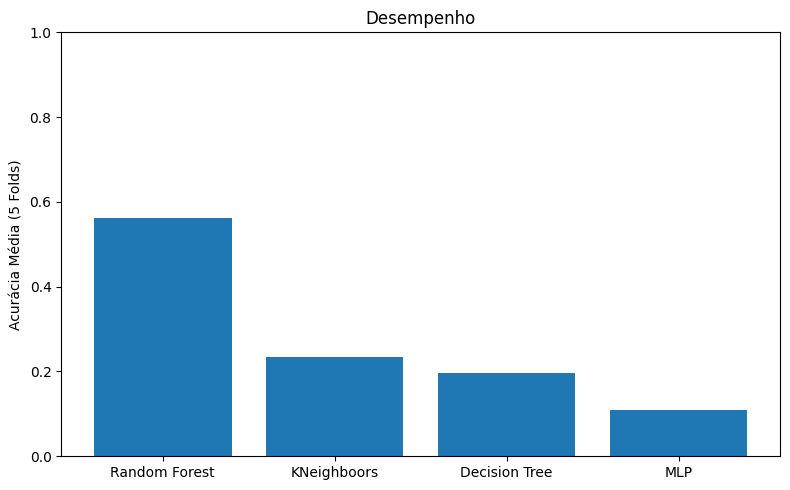

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(models, scores)

plt.ylabel('Acurácia Média (5 Folds)')
plt.title('Desempenho')
plt.ylim(0.0, 1) #Mostra de 0 até 1

plt.tight_layout()
plt.show()